In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:
lake = 'geneva'
folder_path = rf"/storage/alplakes_test/{lake}_100m_2025"
input_folder = os.path.join(folder_path, "outputs_swirl", "eddy_catalogues_final")

output_folder = os.path.join(folder_path, "outputs_swirl", "eddy_statistics")
os.makedirs(output_folder, exist_ok=True)

In [4]:
lvl0_csv_path = os.path.join(input_folder, "lvl0.csv")

In [5]:
df_lvl0 = pd.read_csv(lvl0_csv_path)
df_lvl0 = df_lvl0.set_index('id', drop=False)
df_lvl0['date'] = pd.to_datetime(df_lvl0['date'])

In [6]:
lake_mask = np.load(os.path.join(folder_path, "grid", "mask_lake.npy"))

In [7]:
depths = df_lvl0[['depth_index', 'depth_[m]']].drop_duplicates().sort_values('depth_index').reset_index(drop=True)

In [8]:
Nx=0
Ny=0
if lake == 'lucerne':
    Nx = 288
    Ny = 180
elif lake == 'geneva':
    Nx = 660
    Ny = 245
elif lake == 'neuchatel':
    Nx = 390
    Ny = 96
elif lake == 'zug':
    Nx = 50
    Ny = 140

print(f"Lake: {lake}, Nx: {Nx}, Ny: {Ny}")

Lake: geneva, Nx: 660, Ny: 245


# Volume in upper layer

In [9]:
df_lvl0_upper_layer = df_lvl0[df_lvl0['depth_index'] < 16]

In [9]:
volume_timeserie_upper_layer = df_lvl0_upper_layer.groupby(['date'])['volume_slice_[m3]'].sum()

In [10]:
(volume_timeserie_upper_layer/1e6).to_csv(os.path.join(output_folder, 'volume_timeserie_upper_layer.csv'))

# Surface covered by eddies per depth

In [44]:
df_lake = pd.read_csv(os.path.join(input_folder, "lake_characteristics.csv"))
df_lake = df_lake.set_index('id', drop=False)
df_lake['date'] = pd.to_datetime(df_lake['date'])

In [45]:
i_depth_min = 0
i_depth_max = 50
if lake=='lucerne':
    i_depth_max = 45

In [46]:
xr_surface_lake = df_lake[(
        (df_lake['depth_index'] <= i_depth_max) &
        (df_lake['depth_index'] >= i_depth_min) &
        (df_lake['date'] >= '2025-03-01') &
        (df_lake['date'] <= '2026-03-01')
    )].groupby(['date','depth_[m]'])['surface_area_[m2]'].sum().to_xarray()

In [47]:
xr_surface_eddy = df_lvl0[(
        (df_lvl0['depth_index'] <= i_depth_max) &
        (df_lvl0['depth_index'] >= i_depth_min) &
        (df_lvl0['date'] >= '2025-03-01') &
        (df_lvl0['date'] <= '2026-03-01')
    )].groupby(['date','depth_[m]'])['surface_area_[m2]'].sum().to_xarray()

In [48]:
xr_surface_ratio = 100 * xr_surface_eddy / xr_surface_lake

In [55]:
annual_mean = 100 * xr_surface_eddy.mean(dim=['depth_[m]']).sum().item() / xr_surface_lake.mean(dim=['depth_[m]']).sum().item()

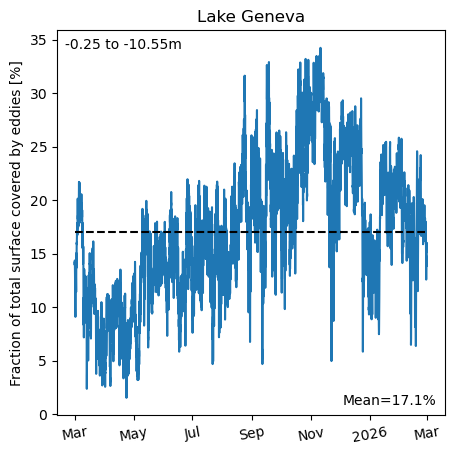

In [28]:
plt.figure(figsize=(5,5))
xr_surface_ratio.mean(dim=['depth_index']).plot()
plt.hlines(annual_mean,
           np.datetime64('2025-03-01'),
           np.datetime64('2026-03-01'),
           linestyles='dashed',
           color='black')

plt.text(0.98,0.02,f'Mean={annual_mean:.1f}%', transform=plt.gca().transAxes, ha='right', va='bottom')
plt.text(0.02, 0.98, f'{depths.iloc[i_depth_min]["depth_[m]"]:.2f} to {depths.iloc[i_depth_max]["depth_[m]"]:.2f}m', transform=plt.gca().transAxes, ha='left', va='top')

plt.title(f'Lake {lake.capitalize()}')
plt.ylabel('Fraction of total surface covered by eddies [%]')
plt.xlabel('')
plt.xticks(rotation=10)
plt.grid(False)

### time-depth

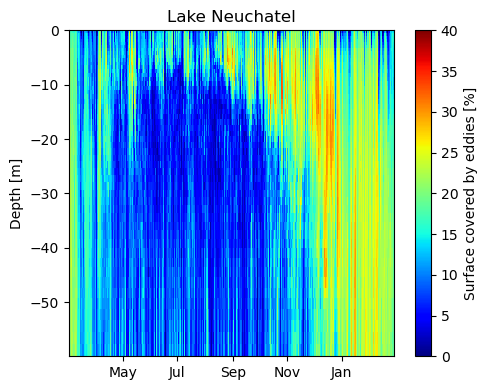

In [49]:
fig, ax = plt.subplots(figsize=(5, 4))

pcm = xr_surface_ratio.plot(y='depth_[m]', cmap="jet", vmin=0, vmax=40)

# Labels
ax.set_xlabel('')
ax.set_ylabel("Depth [m]")
ax.set_title(f"Lake {lake.capitalize()}")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Colorbar
pcm.colorbar.set_label("Surface covered by eddies [%]")

plt.tight_layout()

# Snapshot eddies

In [32]:
def get_eddy_cells_snapshot(df, i_time, i_depth_min, i_depth_max, Nx, Ny):
    depth_filter = (
        (df['depth_index'] <= i_depth_max) &
        (df['depth_index'] >= i_depth_min)
    )
    time_filter = df['time_index'] == i_time

    df_filtered = df.loc[depth_filter & time_filter]

    if len(df_filtered) == 0:
        return np.zeros((Nx, Ny)).T

    i_eddies = []
    j_eddies = []
    for _, row in df_filtered.iterrows():
        i = np.fromstring(row['i_eddy_cells'].strip("[]"), sep=',')
        j = np.fromstring(row['j_eddy_cells'].strip("[]"), sep=',')

        i_eddies.append(i)
        j_eddies.append(j)

    i_eddies = np.concat(i_eddies)
    j_eddies = np.concat(j_eddies)

    df_eddy_cells_snapshot = pd.DataFrame({
                                    'i_eddy_cells': i_eddies.astype(int),
                                    'j_eddy_cells': j_eddies.astype(int)
                                }).drop_duplicates()

    img = np.zeros((Nx, Ny))
    img[df_eddy_cells_snapshot["i_eddy_cells"], df_eddy_cells_snapshot["j_eddy_cells"]] = 1

    return img.T

In [180]:
i_time = 24*(30*4+14)
i_depth_min = 0 #40
i_depth_max = 16 #45

In [181]:
date_snap = df_lvl0[df_lvl0['time_index']==i_time][['time_index','date']].iloc[0]['date']
print(date_snap)

2025-05-15 00:30:00


In [182]:
depths.iloc[i_depth_max]

depth_index    16.0
depth_[m]     -10.3
Name: 16, dtype: float64

In [33]:
eddy_cells_snapshot = get_eddy_cells_snapshot(df_lvl0, 10175, i_depth_min, i_depth_max, Nx, Ny)
eddy_cells_snapshot[~lake_mask[i_depth_min]] = np.nan

Text(0.02, 0.98, '-0.25 to -10.30m')

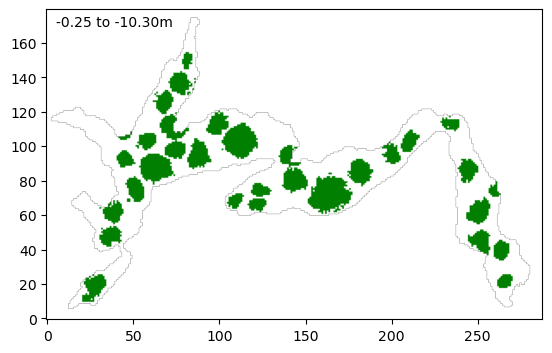

In [35]:
plt.imshow(eddy_cells_snapshot, origin="lower", cmap='ocean_r')
plt.text(0.02, 0.98, f'{depths.iloc[i_depth_min]["depth_[m]"]:.2f} to {depths.iloc[i_depth_max]["depth_[m]"]:.2f}m', transform=plt.gca().transAxes, ha='left', va='top')
#plt.text(0.98, 0.98, f'{date_snap}', transform=plt.gca().transAxes, ha='right', va='top')


# Statistics per location

In [10]:
depths.head()

,depth_index,depth_[m]
0,0,-0.2500
1,1,-0.7575
2,2,-1.2805
3,3,-1.8200
4,4,-2.3760


In [14]:
i_depth_min = 0
i_depth_max = 16
Nt = int(len(np.unique(df_lvl0['date'])))
start_date = pd.to_datetime("2025-03-01")
end_date = pd.to_datetime("2026-03-01")

str_depth_max = str(round(depths.iloc[i_depth_max]['depth_[m]'], 2))
str_depth_min = str(round(depths.iloc[i_depth_min]['depth_[m]'], 2))
print(str_depth_max)
print(str_depth_min)

-10.55
-0.25


eddy_nb = np.zeros((Nx, Ny)).T
for i_idx in range(start_idx,end_idx):
    eddy_cells_snapshot = get_eddy_cells_snapshot(df_lvl0, i_idx, i_depth_min, i_depth_max, Nx, Ny)
    eddy_nb += eddy_cells_snapshot

eddy_perc = 100 * eddy_nb / (Nt+1)
eddy_perc[~lake_mask[i_depth_min]] = np.nan

In [12]:
df = df_lvl0.copy()
df["i_cells"] = df["i_eddy_cells"].map(
    lambda s: np.fromstring(s.strip("[]"), sep=",").astype(int)
)
df["j_cells"] = df["j_eddy_cells"].map(
    lambda s: np.fromstring(s.strip("[]"), sep=",").astype(int)
)

In [15]:
eddy_nb = np.zeros((Nx, Ny), dtype=np.int32)

mask = (
    (df["date"] >= start_date) &
    (df["date"] < end_date) &
    (df["depth_index"] >= i_depth_min) &
    (df["depth_index"] <= i_depth_max)
)

for _, group in df.loc[mask].groupby("time_index"):

    ii = np.concatenate(group["i_cells"].to_numpy())
    jj = np.concatenate(group["j_cells"].to_numpy())

    coords = np.unique(np.column_stack((ii, jj)), axis=0)

    eddy_nb[coords[:, 0], coords[:, 1]] += 1

eddy_perc = 100 * eddy_nb.T / (Nt + 1)
eddy_perc[~lake_mask[i_depth_min]] = np.nan

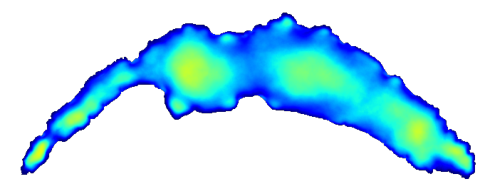

In [17]:
figsize=(5,2.5)
plt.figure(figsize=figsize)
plt.imshow(eddy_perc, cmap='jet', origin="lower", vmin=0, vmax=100)
#cbar = plt.colorbar()
cbar.set_label("Eddy probability [%]")

#plt.text(0.98, 0.98, f'{str_depth_min}m to {str_depth_max}m', transform=plt.gca().transAxes, ha='right', va='top')
plt.grid(False)
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, f"eddy_probability_map_{str_depth_min}m_to_{str_depth_max}m_stratified.png"))

## Clockwise

In [18]:
mask_cw = (
    (df["date"] >= start_date) &
    (df["date"] < end_date) &
    (df["depth_index"] >= i_depth_min) &
    (df["depth_index"] <= i_depth_max) &
    (df['rotation_direction']=='clockwise')
)
eddy_cw_nb = np.zeros((Nx, Ny), dtype=np.int32)
for _, group in df.loc[mask_cw].groupby("time_index"):

    ii = np.concatenate(group["i_cells"].to_numpy())
    jj = np.concatenate(group["j_cells"].to_numpy())

    coords = np.unique(np.column_stack((ii, jj)), axis=0)

    eddy_cw_nb[coords[:, 0], coords[:, 1]] += 1

eddy_cw_perc = 100 * eddy_cw_nb.T / (Nt + 1)
eddy_cw_perc[~lake_mask[i_depth_min]] = np.nan

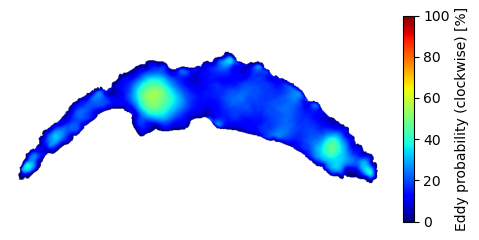

In [19]:
figsize=(5,2.5)
plt.figure(figsize=figsize)
plt.imshow(eddy_cw_perc, cmap='jet', origin="lower", vmin=0, vmax=100)
cbar = plt.colorbar()
cbar.set_label("Eddy probability (clockwise) [%]")

#plt.text(0.98, 0.98, f'{str_depth_min}m to {str_depth_max}m', transform=plt.gca().transAxes, ha='right', va='top')
plt.grid(False)
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, f"eddy_cw_probability_map_{str_depth_min}m_to_{str_depth_max}m_stratified.png"))

## Anti-clockwise

In [20]:
mask_acw = (
    (df["date"] >= start_date) &
    (df["date"] < end_date) &
    (df["depth_index"] >= i_depth_min) &
    (df["depth_index"] <= i_depth_max) &
    (df['rotation_direction']=='anticlockwise')
)
eddy_acw_nb = np.zeros((Nx, Ny), dtype=np.int32)
for _, group in df.loc[mask_acw].groupby("time_index"):

    ii = np.concatenate(group["i_cells"].to_numpy())
    jj = np.concatenate(group["j_cells"].to_numpy())

    coords = np.unique(np.column_stack((ii, jj)), axis=0)

    eddy_acw_nb[coords[:, 0], coords[:, 1]] += 1

eddy_acw_perc = 100 * eddy_acw_nb.T / (Nt + 1)
eddy_acw_perc[~lake_mask[i_depth_min]] = np.nan

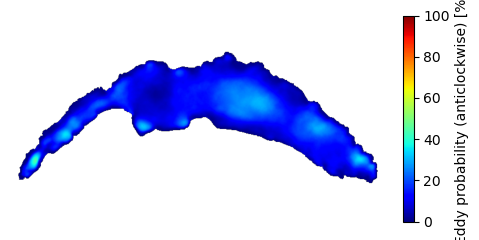

In [21]:
figsize=(5,2.5)
plt.figure(figsize=figsize)
plt.imshow(eddy_acw_perc, cmap='jet', origin="lower", vmin=0, vmax=100)
cbar = plt.colorbar()
cbar.set_label("Eddy probability (anticlockwise) [%]")

#plt.text(0.98, 0.98, f'{str_depth_min}m to {str_depth_max}m', transform=plt.gca().transAxes, ha='right', va='top')
plt.grid(False)
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, f"eddy_acw_probability_map_{str_depth_min}m_to_{str_depth_max}m_stratified.png"))